# A/B-тест: анализ эффективности кросс-продаж (campaign_id = 1)

## 1. Дизайн эксперимента
- **Бизнес-цель:** увеличение выручки за счёт кросс-продаж
- **Гипотеза:** изменение в Variant_A (предположительно, новый дизайн блока кросс-продаж) должно увеличить конверсию и выручку за счёт более заметного предложения для сегмента Deal Seekers.
- **Primary метрика:** конверсия (view → purchase)
- **Secondary метрики:** воронка (view → cart → purchase), RPV
- **Guardrail метрика:** retention (7d, 30d)
- **Период:** 25.10.2021 – 26.11.2021
- **Группы:** Control (11480 сессий), Variant_A (3876 сессий)

In [17]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
from scipy import stats

data = {
    'group': ['Control', 'Variant_A'],
    'sessions': [11480, 3876],
    'purchases': [2297, 728],
    'avg_revenue_per_visitor': [4.06, 3.71],  # средняя выручка на пользователя (RPV)
    'retention_7d': [0.13, 0.11],
    'retention_30d': [0.60, 0.61]
}
df = pd.DataFrame(data)


In [18]:
# Z-тест для пропорций
z_stat, p_value = proportions_ztest(
    count=df['purchases'], 
    nobs=df['sessions'], 
    alternative='two-sided'
)
print(f"Z-статистика: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Разница статистически значима (отвергаем H₀)")
else:
    print("Разница не значима (нет оснований отвергнуть H₀)")

Z-статистика: 1.6599
P-value: 0.0969
Разница не значима (нет оснований отвергнуть H₀)


In [19]:
# Доверительный интервал для разницы конверсий
from statsmodels.stats.proportion import proportion_confint

# CI для каждой группы
ci_control = proportion_confint(df['purchases'][0], df['sessions'][0], method='wilson')
ci_variant = proportion_confint(df['purchases'][1], df['sessions'][1], method='wilson')

print(f"Control CI (95%): [{ci_control[0]*100:.2f}%, {ci_control[1]*100:.2f}%]")
print(f"Variant_A CI (95%): [{ci_variant[0]*100:.2f}%, {ci_variant[1]*100:.2f}%]")

Control CI (95%): [19.29%, 20.75%]
Variant_A CI (95%): [17.58%, 20.04%]


In [20]:
# Поправка Бонферрони (т.к. несколько гипотез на одном датасете)

alpha = 0.05
num_tests = 4  # конверсия, RPV, retention 7d, retention 30d

bonferroni_alpha = alpha / num_tests
print(f"Скорректированный alpha: {bonferroni_alpha:.4f}")

# Расчет p-value для Retention 7 дней
z_ret7, p_ret7 = proportions_ztest(
    count=[14, 4], 
    nobs=[10795, 3792],
    alternative='two-sided'
)

# Расчет p-value для Retention 30 дней
z_ret30, p_ret30 = proportions_ztest(
    count=[65, 23], 
    nobs=[10795, 3792],
    alternative='two-sided'
)

print(f"Retention 7d: p = {p_ret7:.4f}")
print(f"Retention 30d: p = {p_ret30:.4f}")

Скорректированный alpha: 0.0125
Retention 7d: p = 0.7149
Retention 30d: p = 0.9759


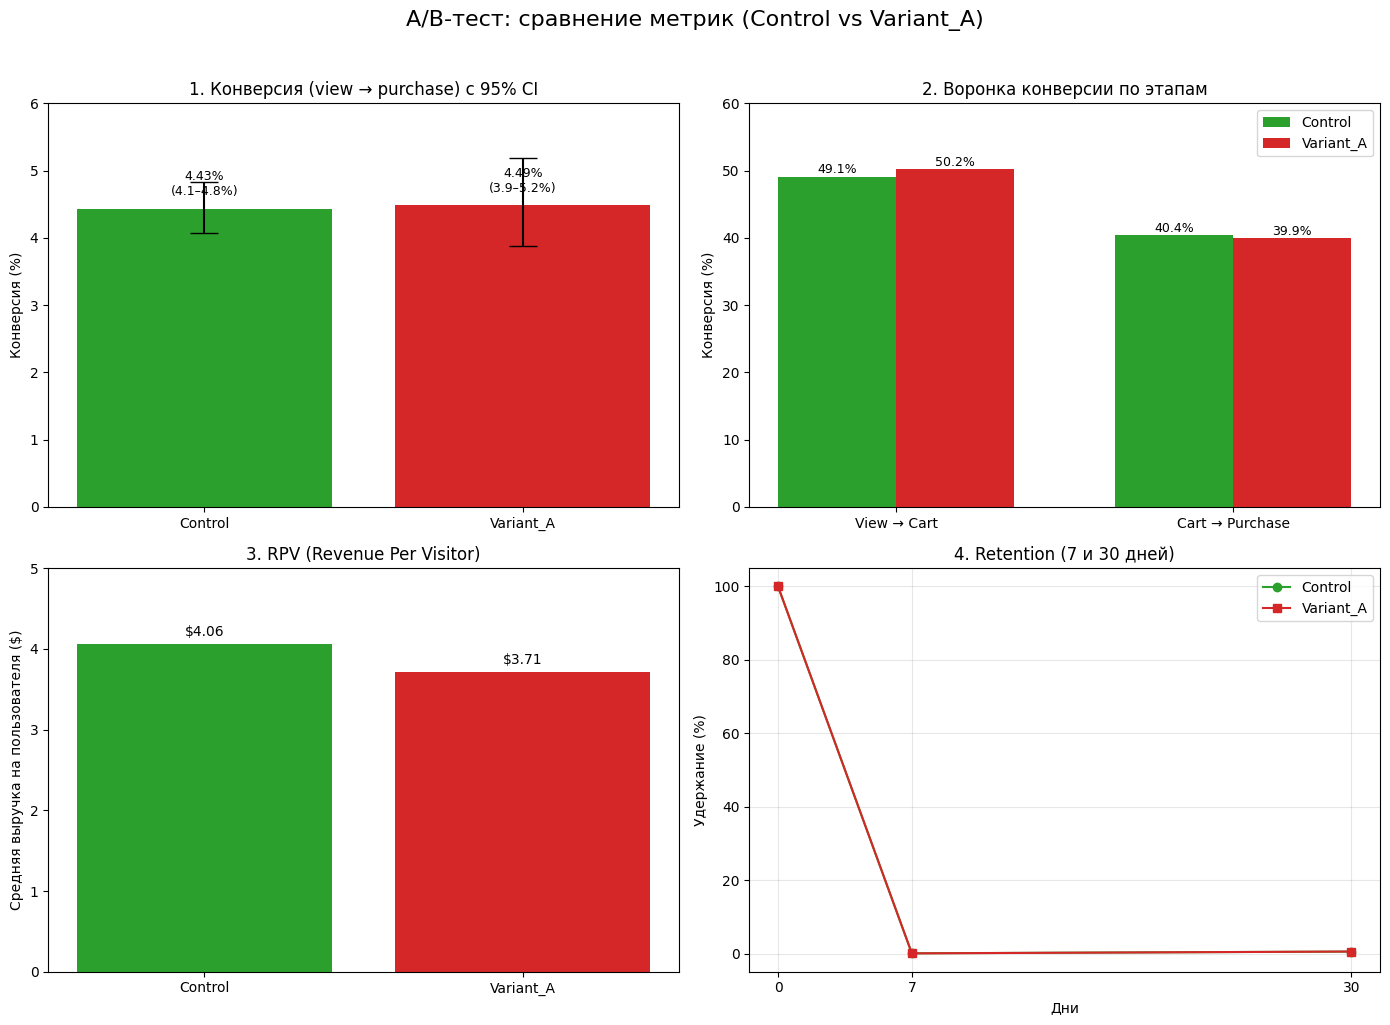

In [25]:
# Построение визуализации для А/В

# Конверсия
groups = ['Control', 'Variant_A']
conversions = [509, 174]
sessions = [11480, 3876]
rates = [c / s * 100 for c, s in zip(conversions, sessions)]
lower, upper = [], []
for c, s in zip(conversions, sessions):
    l, u = proportion_confint(c, s, method='wilson')
    lower.append(l * 100)
    upper.append(u * 100)

# Воронка
stages = ['View → Cart', 'Cart → Purchase']
control_funnel = [49.08, 40.38]
variant_funnel = [50.25, 39.91]

# RPV
rpv_data = [4.06, 3.71]

# Retention
days = [0, 7, 30]
control_ret = [100, 0.13, 0.60]
variant_ret = [100, 0.11, 0.61]

# --- Построение сетки 2×2 ---
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('A/B-тест: сравнение метрик (Control vs Variant_A)', fontsize=16, y=1.02)

# 1. Конверсия с доверительными интервалами
ax = axs[0, 0]
x = np.arange(len(groups))
bars = ax.bar(x, rates, yerr=[np.array(rates) - np.array(lower), np.array(upper) - np.array(rates)],
              capsize=10, color=['#2ca02c', '#d62728'])
ax.set_ylabel('Конверсия (%)')
ax.set_title('1. Конверсия (view → purchase) с 95% CI')
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylim(0, 6)
for bar, rate, l, u in zip(bars, rates, lower, upper):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.2,
            f'{rate:.2f}%\n({l:.1f}–{u:.1f}%)', ha='center', fontsize=9)

# 2. Воронка
ax = axs[0, 1]
x = np.arange(len(stages))
width = 0.35
bars1 = ax.bar(x - width/2, control_funnel, width, label='Control', color='#2ca02c')
bars2 = ax.bar(x + width/2, variant_funnel, width, label='Variant_A', color='#d62728')
ax.set_ylabel('Конверсия (%)')
ax.set_title('2. Воронка конверсии по этапам')
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.legend()
ax.set_ylim(0, 60)
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%', ha='center', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%', ha='center', fontsize=9)

# 3. RPV
ax = axs[1, 0]
ax.bar(groups, rpv_data, color=['#2ca02c', '#d62728'])
ax.set_ylabel('Средняя выручка на пользователя ($)')
ax.set_title('3. RPV (Revenue Per Visitor)')
ax.set_ylim(0, 5)
for i, v in enumerate(rpv_data):
    ax.text(i, v + 0.1, f'${v:.2f}', ha='center', fontsize=10)

# 4. Retention
ax = axs[1, 1]
ax.plot(days, control_ret, marker='o', label='Control', color='#2ca02c')
ax.plot(days, variant_ret, marker='s', label='Variant_A', color='#d62728')
ax.set_xlabel('Дни')
ax.set_ylabel('Удержание (%)')
ax.set_title('4. Retention (7 и 30 дней)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(days)

plt.tight_layout()
plt.show()

**Вывод:** тестируемое изменение не показало статистически значимого эффекта ни по одной из метрик. Мы не можем отвергнуть нулевую гипотезу. Это означает, что Variant_A не является улучшением по сравнению с Control.

**Рекомендации:**
1. Не внедрять Variant_A.
2. Проанализировать, почему этап «cart → purchase» в Variant_A хуже — возможно, изменение отпугивает пользователей на финальном шаге.
3. Сформулировать новую гипотезу для кросс-продаж (например, изменить не дизайн, а предложение — скидку или бесплатную доставку при покупке второго товара).
4. Провести новый A/B-тест с более сильным эффектом (MDE) или на более чувствительной метрике.